In [2]:
import os, time, numpy as np, matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
import sys
sys.path.append('..')
from UnetDataset import EWSDataset, get_transforms
from unetModel import UNet

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


In [11]:
config = {
    "train_img": "Data/train",
    "val_img": "Data/validation",
    "test_img": "Data/test",
    "batch_size": 8,
    "lr": 1e-4,
    "epochs": 50,
    "checkpoint": "checkpoints/unet_best.pth",
}
os.makedirs("checkpoints", exist_ok=True)

In [12]:
train_ds = EWSDataset(config["train_img"], transform=get_transforms("train"))
val_ds = EWSDataset(config["val_img"], transform=get_transforms("val"))
test_ds = EWSDataset(config["test_img"], transform=get_transforms("val"))

train_loader = DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True)
val_loader = DataLoader(val_ds, batch_size=config["batch_size"], shuffle=False)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

print(f"Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")

Train: 142  Val: 24  Test: 24


In [13]:
def dice_loss(pred, target, smooth=1.0):
    pred = torch.sigmoid(pred).view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return 1 - (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def combined_loss(pred, target):
    return 0.5 * nn.BCEWithLogitsLoss()(pred, target) + 0.5 * dice_loss(pred, target)

In [14]:
model     = UNet().to(device)
optimizer = Adam(model.parameters(), lr=config["lr"], weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

train_losses, val_losses = [], []
best_val_loss = float("inf")
train_start   = time.time()

for epoch in range(config["epochs"]):
    # Train
    model.train()
    train_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        loss = combined_loss(model(imgs), masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validate
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            val_loss += combined_loss(model(imgs), masks).item()

    train_loss /= len(train_loader)
    val_loss   /= len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1:3d}/{config['epochs']}  train={train_loss:.4f}  val={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), config["checkpoint"])
        print(f"  → Best model saved")

print(f"\nDone in {(time.time()-train_start)/60:.1f} min")

Epoch   1/50  train=0.4484  val=0.4965
  → Best model saved
Epoch   2/50  train=0.4012  val=0.3236
  → Best model saved
Epoch   3/50  train=0.3649  val=0.2988
  → Best model saved
Epoch   4/50  train=0.3776  val=0.2768
  → Best model saved
Epoch   5/50  train=0.3388  val=0.2865
Epoch   6/50  train=0.3646  val=0.2578
  → Best model saved
Epoch   7/50  train=0.3269  val=0.2385
  → Best model saved
Epoch   8/50  train=0.3412  val=0.2605
Epoch   9/50  train=0.3021  val=0.2154
  → Best model saved
Epoch  10/50  train=0.3127  val=0.2750
Epoch  11/50  train=0.3073  val=0.2208
Epoch  12/50  train=0.3128  val=0.2236
Epoch  13/50  train=0.2979  val=0.2223
Epoch  14/50  train=0.2731  val=0.1866
  → Best model saved
Epoch  15/50  train=0.3066  val=0.2775
Epoch  16/50  train=0.2934  val=0.2247
Epoch  17/50  train=0.2906  val=0.2445
Epoch  18/50  train=0.2833  val=0.2271
Epoch  19/50  train=0.2731  val=0.1857
  → Best model saved
Epoch  20/50  train=0.2683  val=0.2213
Epoch  21/50  train=0.2662  val

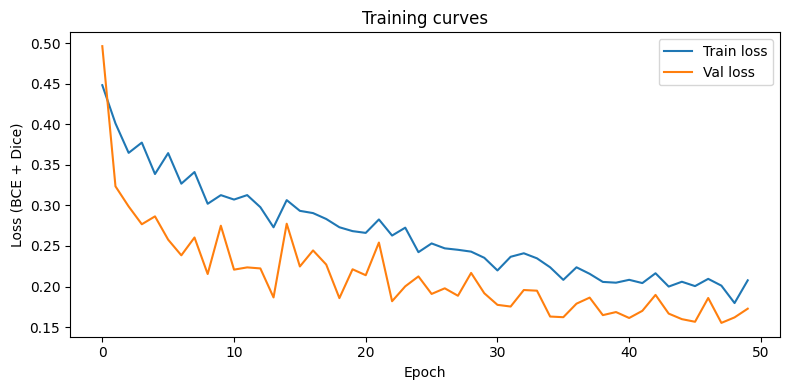

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (BCE + Dice)")
plt.title("Training curves")
plt.legend()
plt.tight_layout()
plt.show()